In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("loan_approval_data.csv")

In [3]:
df.head()
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,501.220000,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,48.000000
std,289.608451,5061.632859,2943.161570,11.139797,1.105067,71.346015,1.406246,0.144341,5860.736885,14345.696031,11504.142575,24.245322
min,1.000000,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000
25%,250.250000,6730.750000,2472.750000,30.250000,1.000000,616.250000,1.000000,0.220000,4760.250000,12698.250000,9806.250000,24.000000
50%,499.500000,10548.000000,5205.500000,40.000000,1.000000,678.000000,2.000000,0.340000,9880.500000,24321.000000,21210.500000,48.000000
75%,752.750000,15190.000000,7620.750000,49.000000,2.000000,737.000000,3.000000,0.480000,15074.500000,36947.000000,30263.000000,72.000000
max,1000.000000,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000


Handle Missing Values

In [4]:
categorical_cols = df.select_dtypes(include = ["object"]).columns
numerical_cols = df.select_dtypes(include = ["number"]).columns

In [5]:
from sklearn.impute import SimpleImputer

num_imp = SimpleImputer(strategy = "mean")
df[numerical_cols] = num_imp.fit_transform(df[numerical_cols])

In [6]:
cat_imp = SimpleImputer(strategy = "most_frequent")
df[categorical_cols] = cat_imp.fit_transform(df[categorical_cols])

# EDA 

Text(0.5, 1.0, 'Loan approved or not')

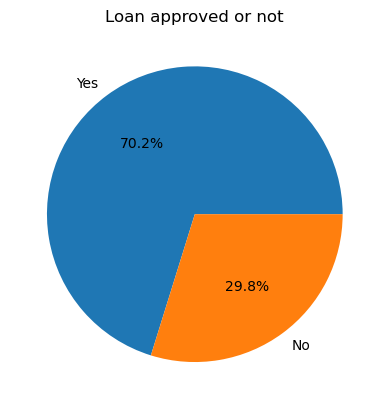

In [7]:
classes_count = df["Loan_Approved"].value_counts()

plt.pie(classes_count, labels = ["Yes", "No"], autopct = "%1.1f%%")
plt.title("Loan approved or not")

[Text(0, 0, '722'), Text(0, 0, '278')]

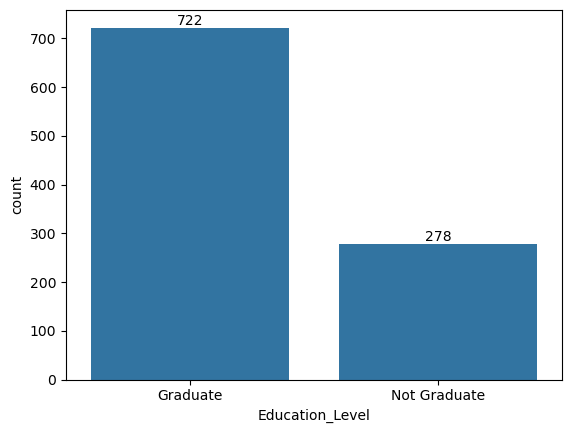

In [8]:
#gender_cnt = df["Gender"].value_counts()
#ax = sns.barplot(gender_cnt)
#ax.bar_label(ax.containers[0])

edu_cnt = df["Education_Level"].value_counts()
ax = sns.barplot(edu_cnt)
ax.bar_label(ax.containers[0])

<Axes: xlabel='Applicant_Income', ylabel='Count'>

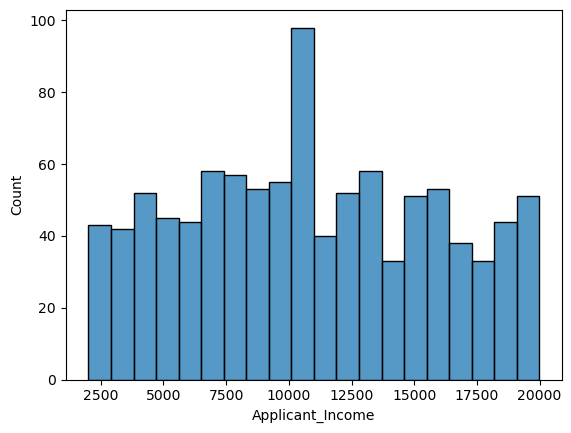

In [9]:
sns.histplot(
    data = df,
    x = "Applicant_Income",
    bins = 20
)

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

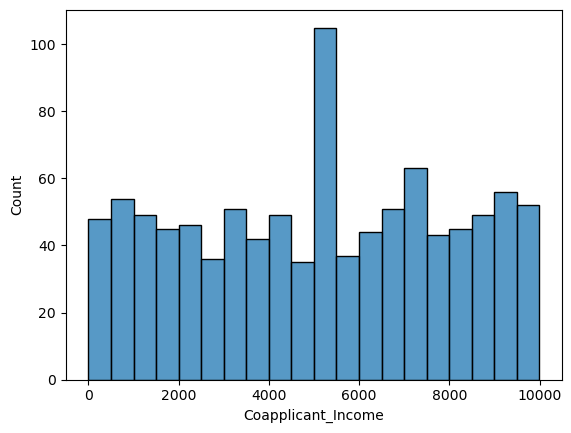

In [10]:
sns.histplot(
    data = df,
    x = "Coapplicant_Income",
    bins = 20
)

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

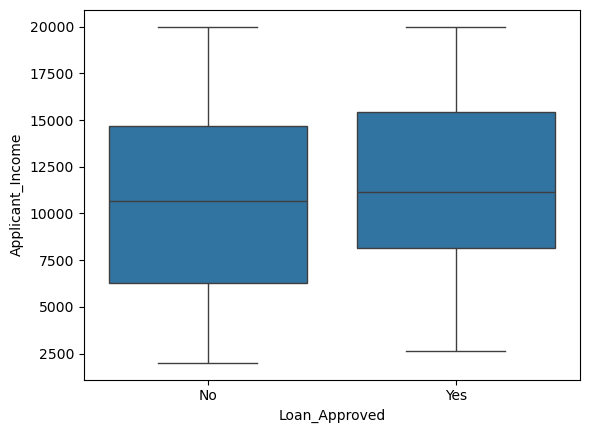

In [11]:
sns.boxplot(
    data = df,
    x = "Loan_Approved",
    y = "Applicant_Income"
)

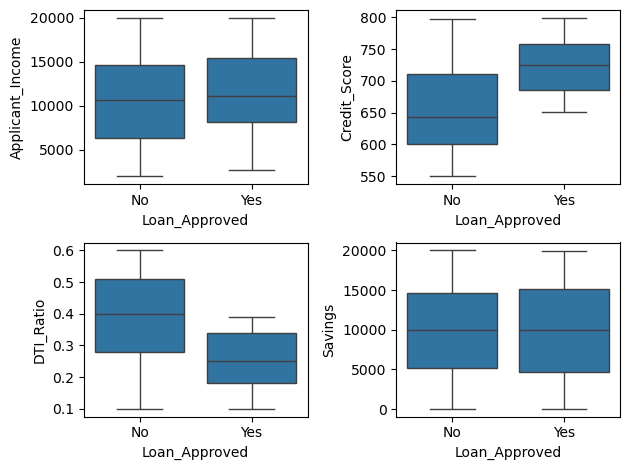

In [12]:
fig, axes = plt.subplots(2,2)

sns.boxplot(ax = axes[0,0], data = df, x = "Loan_Approved", y = "Applicant_Income")
sns.boxplot(ax = axes[0,1], data = df, x = "Loan_Approved", y = "Credit_Score")
sns.boxplot(ax = axes[1,0], data = df, x = "Loan_Approved", y = "DTI_Ratio")
sns.boxplot(ax = axes[1,1], data = df, x = "Loan_Approved", y = "Savings")

plt.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

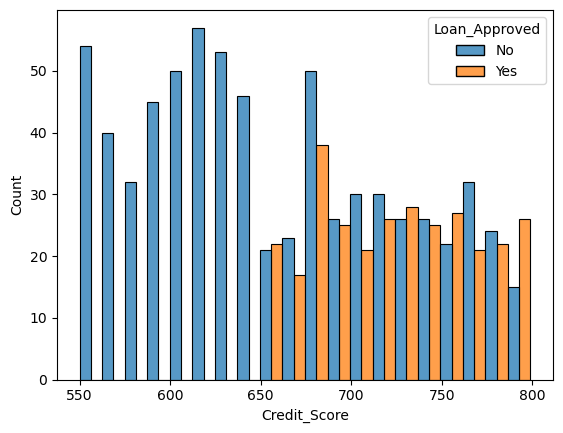

In [13]:
sns.histplot(
    data = df,
    x = "Credit_Score",
    hue = "Loan_Approved",
    multiple = "dodge",
    bins = 20
)

<Axes: xlabel='Applicant_Income', ylabel='Count'>

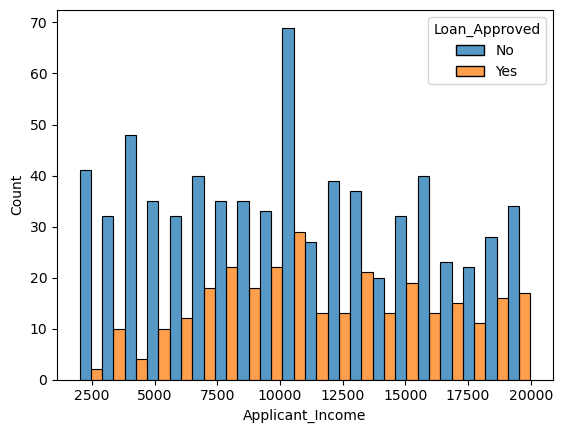

In [14]:
sns.histplot(
    data = df,
    x = "Applicant_Income",
    hue = "Loan_Approved",
    multiple = "dodge",
    bins = 20
)

In [15]:
df = df.drop("Applicant_ID", axis = 1)

In [16]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

le = LabelEncoder()
df["Education_Level"] = le.fit_transform(df["Education_Level"])
df["Loan_Approved"] = le.fit_transform(df["Loan_Approved"])

In [17]:
cols = ["Marital_Status", "Employment_Status", "Loan_Purpose", "Gender", "Employer_Category","Property_Area"]

ohe = OneHotEncoder(drop = "first", sparse_output = False, handle_unknown = "ignore")

encoded = ohe.fit_transform(df[cols])

encoded_df = pd.DataFrame(encoded, columns = ohe.get_feature_names_out(cols), index = df.index)

df = pd.concat([df.drop(columns = cols), encoded_df], axis = 1)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Dependents                       1000 non-null   float64
 4   Credit_Score                     1000 non-null   float64
 5   Existing_Loans                   1000 non-null   float64
 6   DTI_Ratio                        1000 non-null   float64
 7   Savings                          1000 non-null   float64
 8   Collateral_Value                 1000 non-null   float64
 9   Loan_Amount                      1000 non-null   float64
 10  Loan_Term                        1000 non-null   float64
 11  Education_Level                  1000 non-null   int64  
 12  Loan_Approved        

In [19]:
num_cols = df.select_dtypes(include = "number")
corr_matrix = num_cols.corr()

In [20]:
num_cols.corr()["Loan_Approved"].sort_values(ascending = False)

Loan_Approved                      1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employer_Category_MNC              0.069049
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                        -0.023811
Existing_Loans                    -0.034794
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed      -0.044464
Education_Level                 

<Axes: >

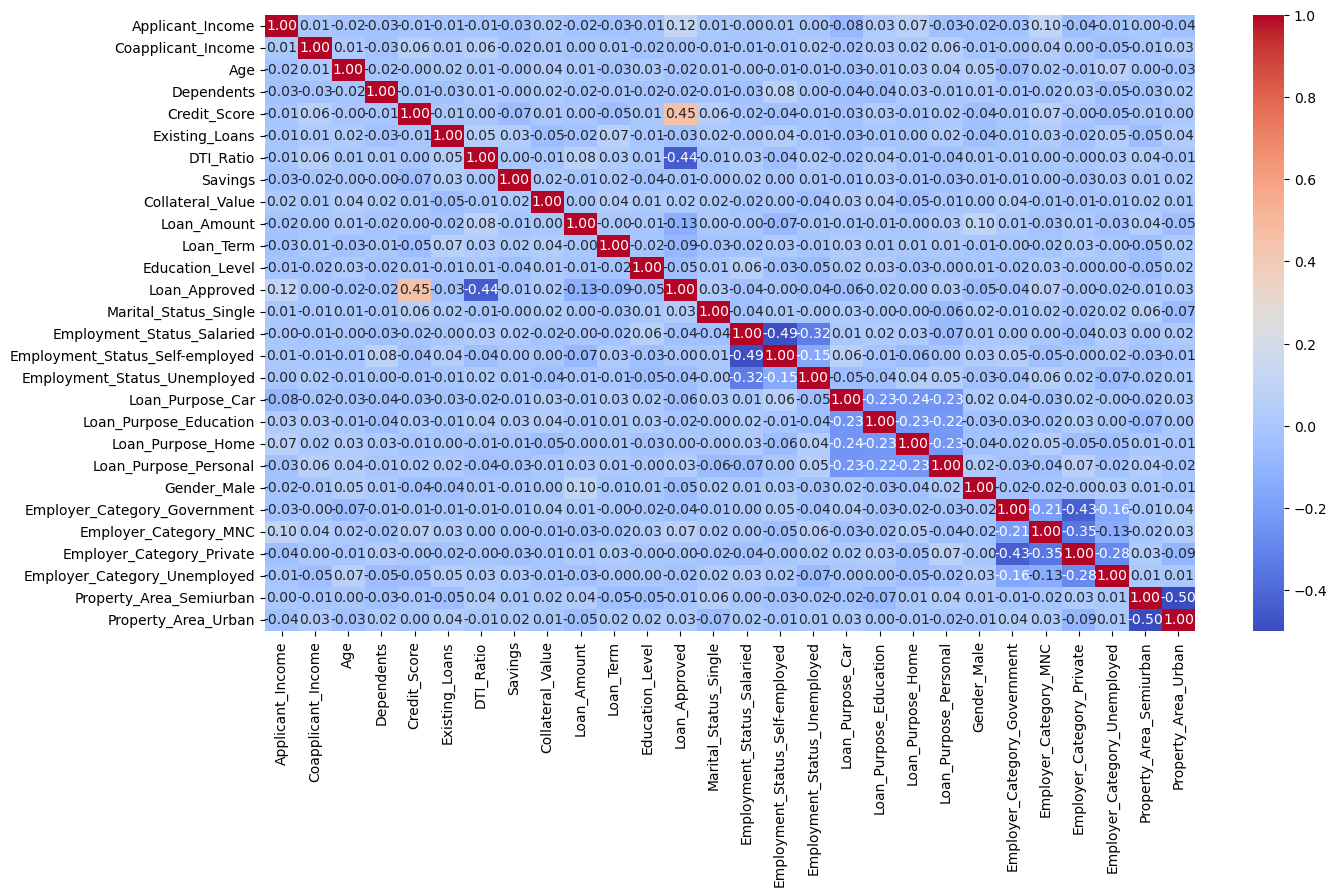

In [21]:
num_cols = df.select_dtypes(include = "number")
corr_matrix = num_cols.corr()

plt.figure(figsize = (15, 8))
sns.heatmap(
    corr_matrix,
    annot = True,
    fmt = ".2f",
    cmap = "coolwarm"
)

In [22]:
X = df.drop("Loan_Approved", axis = 1)
y = df["Loan_Approved"]

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [27]:
#Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, confusion_matrix

lr_model = LogisticRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred = lr_model.predict(X_test_scaled)

print("Logistic Regression: ")
print("Precision Score", precision_score(y_test, y_pred))
print("recall_score", recall_score(y_test, y_pred))
print("accuracy_score", accuracy_score(y_test, y_pred))
print("f1_score", f1_score(y_test, y_pred))
print("confusion_matrix", confusion_matrix(y_test, y_pred))

Logistic Regression: 
Precision Score 0.7833333333333333
recall_score 0.7704918032786885
accuracy_score 0.865
f1_score 0.7768595041322314
confusion_matrix [[126  13]
 [ 14  47]]


In [28]:
#KNN clasifier

from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
y_pred = knn_model.predict(X_test_scaled)

print("KNN : ")
print("Precision Score", precision_score(y_test, y_pred))
print("recall_score", recall_score(y_test, y_pred))
print("accuracy_score", accuracy_score(y_test, y_pred))
print("f1_score", f1_score(y_test, y_pred))
print("confusion_matrix", confusion_matrix(y_test, y_pred))

KNN : 
Precision Score 0.6274509803921569
recall_score 0.5245901639344263
accuracy_score 0.76
f1_score 0.5714285714285714
confusion_matrix [[120  19]
 [ 29  32]]


In [29]:
#Naive Bayes

from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)
y_pred = nb_model.predict(X_test_scaled)

print("Naive Bayes: ")
print("Precision Score", precision_score(y_test, y_pred))
print("recall_score", recall_score(y_test, y_pred))
print("accuracy_score", accuracy_score(y_test, y_pred))
print("f1_score", f1_score(y_test, y_pred))
print("confusion_matrix", confusion_matrix(y_test, y_pred))

Naive Bayes: 
Precision Score 0.8035714285714286
recall_score 0.7377049180327869
accuracy_score 0.865
f1_score 0.7692307692307693
confusion_matrix [[128  11]
 [ 16  45]]


In [30]:
df["DTI_Ratio_sq"] = df["DTI_Ratio"] ** 2
df["Credit_Score_sq"] = df["Credit_Score"] ** 2

X = df.drop(columns=["Loan_Approved", "Credit_Score", "DTI_Ratio"])
y = df["Loan_Approved"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
#Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, confusion_matrix

lr_model = LogisticRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred = lr_model.predict(X_test_scaled)

print("Logistic Regression: ")
print("Precision Score", precision_score(y_test, y_pred))
print("recall_score", recall_score(y_test, y_pred))
print("accuracy_score", accuracy_score(y_test, y_pred))
print("f1_score", f1_score(y_test, y_pred))
print("confusion_matrix", confusion_matrix(y_test, y_pred))

Logistic Regression: 
Precision Score 0.7903225806451613
recall_score 0.8032786885245902
accuracy_score 0.875
f1_score 0.7967479674796748
confusion_matrix [[126  13]
 [ 12  49]]
